# Loading experimental data and plotting it

This notebook demonstrates how to:

1. locate and inspect a comma-separated values (CSV) file;
2. load its named columns with NumPy;
3. plot measurements against time;
4. display measurement uncertainty;
5. calculate and plot a derived quantity.

The example dataset represents a temperature sensor responding after a heater is switched on.

## 1. Import the required libraries

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

## 2. Locate and inspect the data file

The CSV file must be in the same folder as this notebook. Using `Path` makes the filename easy to read and change.

In [2]:
data_file = Path("temperature_sensor_data.csv")

if not data_file.exists():
    raise FileNotFoundError(
        f"Could not find {data_file.resolve()}. "
        "Place the CSV file in the same folder as the notebook."
    )

print("Loading:", data_file.resolve())

Loading: /Users/ianeames/Library/CloudStorage/Dropbox-fluidboss/Ian Eames/teaching/Mathematics_Physics/Lecture2/JupyterLabs/temperature_sensor_data.csv


In [3]:
# Preview the header and first four measurements before loading the file.
with data_file.open("r", encoding="utf-8") as file:
    for _ in range(5):
        print(file.readline().strip())

time_s,temperature_C,uncertainty_C
0,20.1,0.20
3,20.4,0.20
6,20.8,0.20
9,21.3,0.20


## 3. Load the CSV data

`np.genfromtxt` reads numerical data from a text file. Setting `names=True` uses the first row as the column names.

In [4]:
data = np.genfromtxt(
    data_file,
    delimiter=",",
    names=True,
    encoding="utf-8",
)

print("Column names:", data.dtype.names)
print("Number of measurements:", data.size)
print("First measurement:", data[0])

Column names: ('time_s', 'temperature_C', 'uncertainty_C')
Number of measurements: 21
First measurement: (0.0, 20.1, 0.2)


## 4. Extract the columns

In [5]:
time = data["time_s"]
temperature = data["temperature_C"]
uncertainty = data["uncertainty_C"]

print("Time range:", time.min(), "to", time.max(), "s")
print("Temperature range:", temperature.min(), "to", temperature.max(), "°C")

Time range: 0.0 to 60.0 s
Temperature range: 20.1 to 28.2 °C


## 5. Make a simple plot

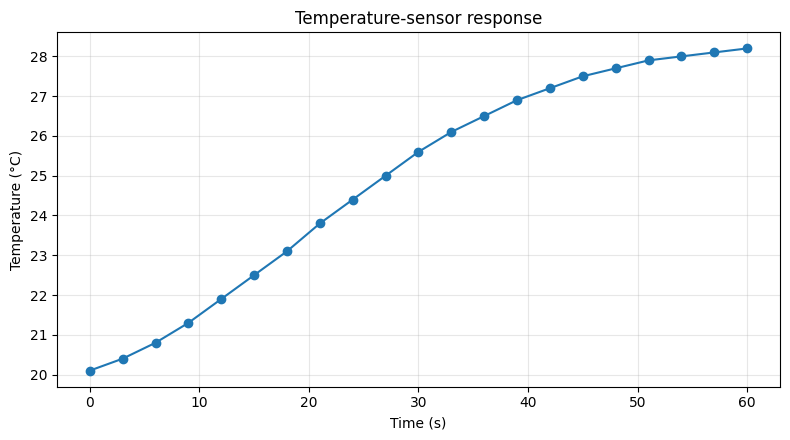

In [6]:
plt.figure(figsize=(8, 4.5))
plt.plot(time, temperature, marker="o", color="tab:blue")
plt.xlabel("Time (s)")
plt.ylabel("Temperature (°C)")
plt.title("Temperature-sensor response")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Include measurement uncertainty

An error-bar plot communicates both the measured value and its uncertainty. Here the vertical error bars are supplied by the `uncertainty_C` column.

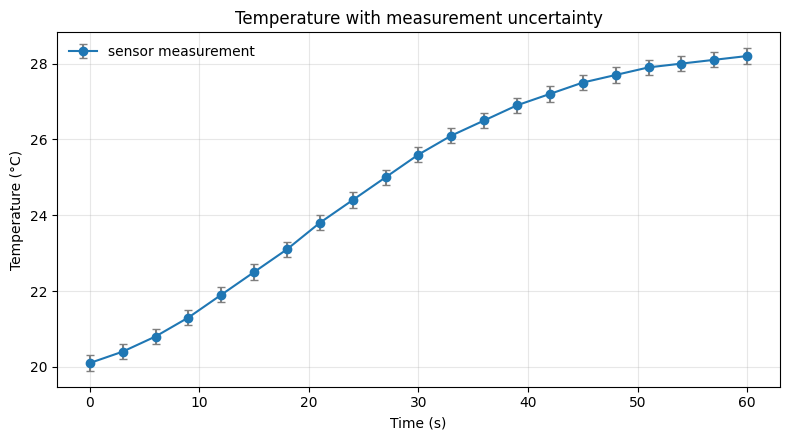

In [7]:
plt.figure(figsize=(8, 4.5))
plt.errorbar(
    time,
    temperature,
    yerr=uncertainty,
    fmt="o-",
    color="tab:blue",
    ecolor="tab:gray",
    capsize=3,
    label="sensor measurement",
)
plt.xlabel("Time (s)")
plt.ylabel("Temperature (°C)")
plt.title("Temperature with measurement uncertainty")
plt.grid(alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

## 7. Calculate and plot a derived quantity

The rate of temperature change can be estimated numerically using `np.gradient`:

$$
\frac{dT}{dt} \approx \texttt{np.gradient(temperature, time)}.
$$

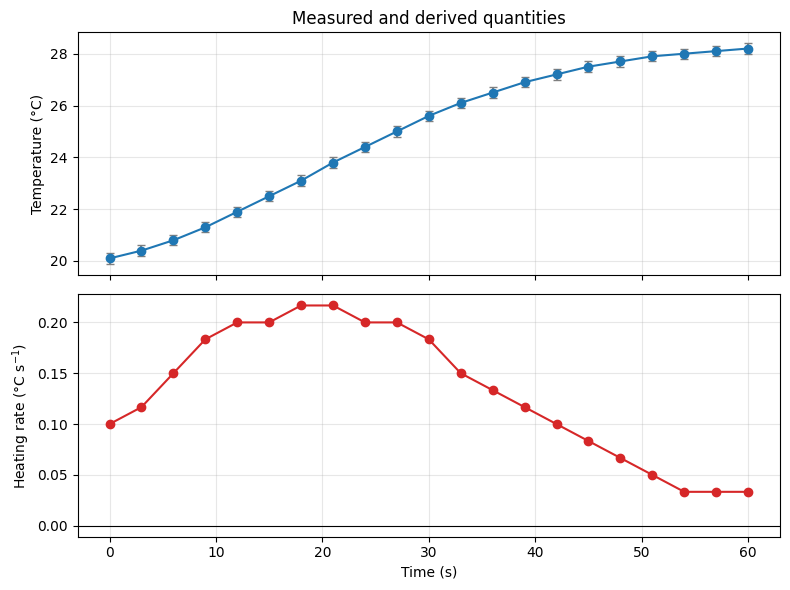

In [8]:
heating_rate = np.gradient(temperature, time)

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axes[0].errorbar(
    time,
    temperature,
    yerr=uncertainty,
    fmt="o-",
    color="tab:blue",
    ecolor="tab:gray",
    capsize=3,
)
axes[0].set_ylabel("Temperature (°C)")
axes[0].set_title("Measured and derived quantities")
axes[0].grid(alpha=0.3)

axes[1].plot(time, heating_rate, "o-", color="tab:red")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel(r"Heating rate (°C s$^{-1}$)")
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()

## 8. Save a figure

Figure saved as: /Users/ianeames/Library/CloudStorage/Dropbox-fluidboss/Ian Eames/teaching/Mathematics_Physics/Lecture2/JupyterLabs/temperature_sensor_plot.png


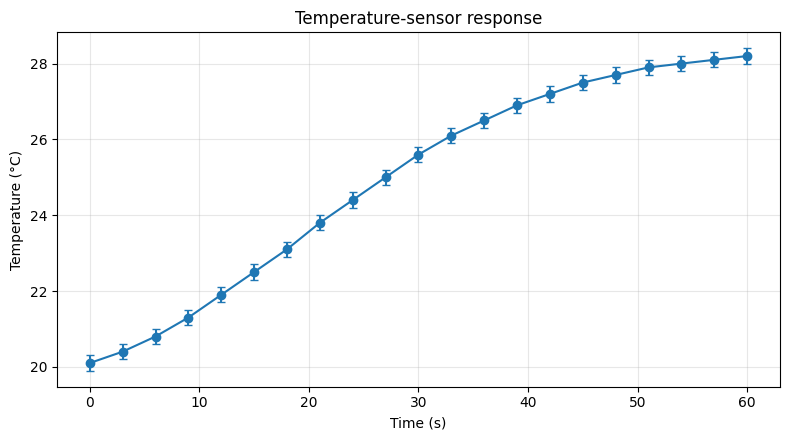

In [9]:
output_file = Path("temperature_sensor_plot.png")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(
    time,
    temperature,
    yerr=uncertainty,
    fmt="o-",
    capsize=3,
    color="tab:blue",
)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Temperature-sensor response")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(output_file, dpi=200, bbox_inches="tight")

print("Figure saved as:", output_file.resolve())
plt.show()

## Exercises

1. Change the line colour, marker and line style.
2. Plot only the measurements between 15 s and 45 s.
3. Find and print the maximum temperature and the time at which it occurs.
4. Add a second CSV column representing a second sensor and plot both sensors on the same axes.
5. Replace the temperature dataset with data from your own experiment. Keep the column names clear and include units in the plot labels.